In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df = pd.read_pickle('../data/processed/emails_preprocessed.pkl')
style_df = pd.read_pickle('../data/features/stylistic_features.pkl')

print(f"Loaded {len(df):,} emails")
print(f"Stylistic features shape: {style_df.shape}")

Loaded 458,386 emails
Stylistic features shape: (458386, 9)


In [2]:
# Standardise features
scaler = StandardScaler()
style_scaled = scaler.fit_transform(style_df.fillna(0))

# Isolation Forest
iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42,
    n_estimators=200
)
df['anomaly_iso'] = iso_forest.fit_predict(style_scaled)
df['anomaly_score'] = iso_forest.decision_function(style_scaled)

# Results
anomalies = df[df['anomaly_iso'] == -1]
print(f"Total anomalies detected: {len(anomalies):,}")
print(f"Anomaly rate: {len(anomalies)/len(df)*100:.1f}%")
print(f"\nTop anomalous users:")
print(anomalies['user'].value_counts().head(10))

Total anomalies detected: 22,907
Anomaly rate: 5.0%

Top anomalous users:
user
dasovich-j    2031
kean-s        1330
kaminski-v     668
bass-e         608
guzman-m       545
germany-c      536
symes-k        511
farmer-d       505
jones-t        475
linder-e       474
Name: count, dtype: int64


In [3]:
from sklearn.cluster import MiniBatchKMeans

# K-Means clustering (much faster than DBSCAN on large data)
kmeans = MiniBatchKMeans(n_clusters=10, random_state=42, batch_size=1000)
df['cluster'] = kmeans.fit_predict(style_scaled)

# Find small clusters (potential anomalous groups)
cluster_counts = df['cluster'].value_counts()
print("Cluster sizes:")
print(cluster_counts)
print(f"\nSmallest clusters (potential anomalies):")
small_clusters = cluster_counts[cluster_counts < cluster_counts.mean()].index
print(f"Clusters smaller than average: {list(small_clusters)}")
print(f"Emails in small clusters: {df[df['cluster'].isin(small_clusters)].shape[0]:,}")

Cluster sizes:
cluster
2    121879
1    107845
5    107146
8     56559
0     19092
3     18354
6     11590
4      8164
7      4767
9      2990
Name: count, dtype: int64

Smallest clusters (potential anomalies):
Clusters smaller than average: [0, 3, 6, 4, 7, 9]
Emails in small clusters: 64,957


In [4]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df['anomaly_lof'] = lof.fit_predict(style_scaled)
df['lof_score'] = lof.negative_outlier_factor_

# Compare methods
print("Agreement between methods:")
both_anomalous = ((df['anomaly_iso'] == -1) & (df['anomaly_lof'] == -1)).sum()
print(f"Both ISO Forest + LOF flagged: {both_anomalous:,}")
print(f"Only ISO Forest: {((df['anomaly_iso'] == -1) & (df['anomaly_lof'] == 1)).sum():,}")
print(f"Only LOF: {((df['anomaly_iso'] == 1) & (df['anomaly_lof'] == -1)).sum():,}")

# Emails flagged by BOTH methods are the strongest anomaly candidates
df['strong_anomaly'] = (df['anomaly_iso'] == -1) & (df['anomaly_lof'] == -1)
print(f"\nStrong anomalies (both methods): {df['strong_anomaly'].sum():,}")

Agreement between methods:
Both ISO Forest + LOF flagged: 3,184
Only ISO Forest: 19,723
Only LOF: 19,736

Strong anomalies (both methods): 3,184


/Users/noorhenigal/projects/enron-nlp-forensics/venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


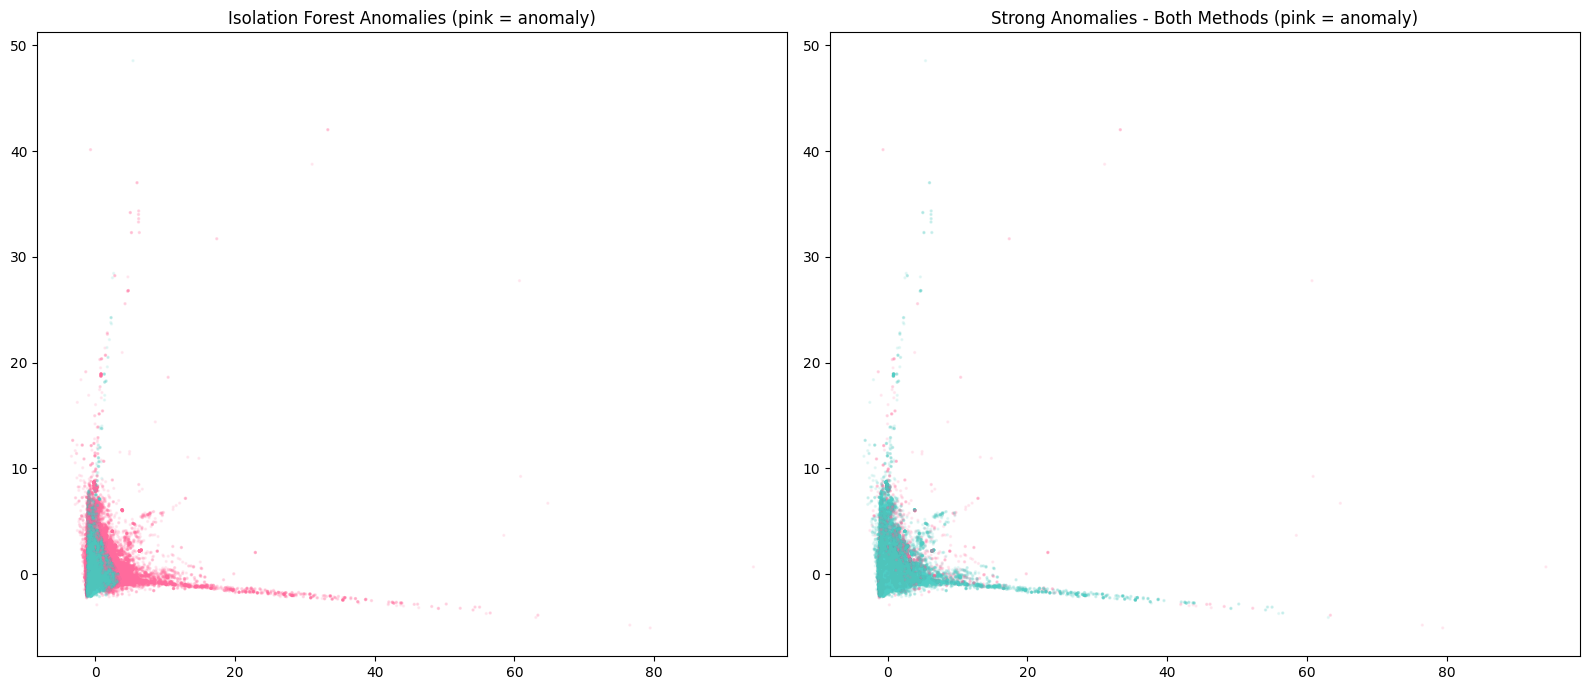

In [5]:
# PCA to 2D for visualisation
pca_2d = PCA(n_components=2)
coords = pca_2d.fit_transform(style_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Isolation Forest results
colors = ['#4ecdc4' if x == 1 else '#ff6b9d' for x in df['anomaly_iso']]
axes[0].scatter(coords[:, 0], coords[:, 1], c=colors, alpha=0.1, s=2)
axes[0].set_title('Isolation Forest Anomalies (pink = anomaly)')

# Strong anomalies (both methods)
colors = ['#4ecdc4' if x == False else '#ff6b9d' for x in df['strong_anomaly']]
axes[1].scatter(coords[:, 0], coords[:, 1], c=colors, alpha=0.1, s=2)
axes[1].set_title('Strong Anomalies - Both Methods (pink = anomaly)')

plt.tight_layout()
plt.savefig('../results/figures/anomaly_detection_comparison.png', dpi=150)
plt.show()

In [6]:
df.to_pickle('../data/processed/emails_with_anomalies.pkl')
print(f"Saved {len(df):,} emails with anomaly labels")

Saved 458,386 emails with anomaly labels
